In [12]:
import pickle
import numpy as np
from pathlib import Path
import pandas as pd 
import librosa 
import IPython.display as ipd
import soundfile as sf

%matplotlib inline 

import matplotlib.pyplot as plt 

### Re-cut SWC stimuli for better excerpts in binaural experiment 

In [13]:
path_to_dir = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024')
path_to_dir.mkdir(exist_ok = True, parents=True)


In [14]:
class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 

In [15]:
word_list = list(class_map.keys())

In [16]:
with open("word_list_for_binaural_sentences.pkl", "rb") as f:
    target_word_list =  pickle.load(f)

### First, re-screen SWC for excerpts in this list of target words

In [17]:
swc_fname = '/om2/user/msaddler/spatial_audio_pipeline/assets/swc/manifest_all_words.pdpkl'
swc_main_df = pd.read_pickle(swc_fname)
print(swc_main_df.shape)

(1006299, 13)


In [18]:
## Throw out bad talkers

bad_talker_names = ['wikipedia', 'viktor-o-ledenyov',  'acerperi', 'bowie-media']

In [19]:
swc_main_df = swc_main_df[~swc_main_df.client_id.str.contains('|'.join(bad_talker_names))]

In [20]:
### remove examples that end too close to edge of file 

tol_in_s = .5 
swc_main_df = swc_main_df[swc_main_df.clip_end_in_s <= (swc_main_df.total_file_duration_in_s - tol_in_s)]


In [21]:
swc_main_df.shape

(991867, 13)

In [22]:
gender_balanced_swc = swc_main_df[swc_main_df.word.isin(target_word_list)].groupby(['gender', 'word']).sample(1, replace=False, random_state=0).reset_index()

In [23]:
### Print n unique words
gender_balanced_swc.word.nunique()

488

In [24]:
# get distractor df 

distractor_df = swc_main_df[(~swc_main_df.index.isin(gender_balanced_swc.index)) & (swc_main_df.word.isin(target_word_list))]
cue_df = swc_main_df[(~swc_main_df.index.isin(gender_balanced_swc.index))]

In [25]:
#rename index
gender_balanced_swc.rename(columns={'index':'orig_df_ix'}, inplace=True)

In [16]:
### Write parent manifest to dir 
out_name = path_to_dir / 'test_stim_orig_manifest.pdpkl'
# gender_balanced_swc.to_pickle(out_name)

In [17]:
gender_balanced_swc.head()

,orig_df_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,split_int,sr,src_fn,total_file_duration_in_s,word
0,601538,laura-s,0.29,1205.07,1204.78,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,1796.176689,about
1,638828,dolliellama,0.36,737.92,737.56,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,4871.649524,above
2,249863,ama1016,0.52,371.41,370.89,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,488.501406,access
3,127418,popularoutcast,0.47,3399.30,3398.83,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,3717.672925,across
4,961747,sedola,0.42,1898.92,1898.50,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,2335.023311,action


In [30]:
# get manifest for cue and distractor excerpts 

bg_df = swc_main_df[(~swc_main_df.index.isin(gender_balanced_swc.orig_df_ix)) & (swc_main_df.word.isin(word_list))].reset_index()
bg_df.rename(columns={'index':'orig_df_ix'}, inplace=True)
print(bg_df.shape)
# get partition of swc

(316748, 14)


### Look at power spectrum of examples

In [31]:
from scipy.fft import rfft, rfftfreq


def plot_power_spec(wav, axs, sr=16000, title=''):
    # get specturm of the audio
    ps = np.abs(rfft(wav))
    ps_to_db = 20*np.log10(ps/ps.max())
    freqs = rfftfreq(wav.size, 1/sr)
    idx = np.argsort(freqs)
    # axs.semilogx(freqs[idx], ps_to_db[idx], linewidth=0.5, alpha=0.9)
    axs.plot(freqs[idx], ps_to_db[idx], linewidth=0.5, alpha=0.9)
    axs.axis([0, sr//2 + 1000, -100, 5]) # 40 is lowest freq of 40Hz
    
    # get average power between 10000 and 16000 Hz
    avg_power = np.mean(ps_to_db[(freqs >= 10000) & (freqs <= 16000)])
    print(avg_power)

    axs.set_ylabel('Power spectrum (dB)')
    axs.set_xlabel('Frequency (Hz)')
    axs.set_title(title)
    axs.axvline(16000, linewidth=0.5, color='k', linestyle='--')
    # axs.set_xscale('log')
    # axs.set_ylim(-100, 0)
    return None 

either
-57.902184


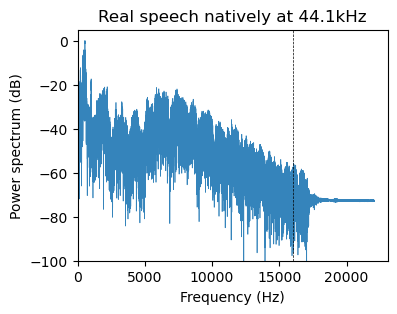

In [33]:
### For row target in gender_balanced_swc load 3 seconds from the src_fn centered on the clip_start_in_s and clip_end_in_s

total_dur = 3 # in seconds
human_dur = 2 # in seconds 
SR = 44_100

def get_window_bounds(clip_dur_in_s, clip_start_in_s, clip_end_in_s, total_dur):
    
    offset = (total_dur  - clip_dur_in_s) / 2
    return clip_start_in_s - offset, clip_end_in_s + offset
# given clip_dur_in_s find lag and lead time around clip_end_in_s and clip_start_in_s

row = gender_balanced_swc.iloc[120]
# print(row)
src_fn = row['src_fn']
clip_start_in_s = row['clip_start_in_s']
clip_end_in_s = row['clip_end_in_s']
clip_dur_in_s = row['clip_dur_in_s']
word = row['word']
onset, offset = get_window_bounds(clip_dur_in_s, clip_start_in_s, clip_end_in_s, total_dur)
# print(onset, offset)
wav, sr = librosa.load(src_fn, sr=SR, offset=onset, duration=total_dur, dtype=np.float32)
print(word)

fig, axs = plt.subplots(figsize=(4,3))
plot_power_spec(wav, axs, title='Real speech natively at 44.1kHz', sr=sr)
ipd.display(ipd.Audio(wav, rate=sr, normalize=False))




## Cut cue, target, and distractor from SWC. 

Distractors must use in-vocabulary words to enable confusions 

In [34]:
from tqdm.auto import tqdm

In [35]:
### Write parent manifest to dir 
out_name = path_to_dir / 'test_stim_orig_manifest.pdpkl'
gender_balanced_swc = pd.read_pickle(out_name)

In [38]:
### Demo signal sampling proceedure 
np.random.seed(0)
same_sex_dist_df = gender_balanced_swc.copy()
different_sex_dist_df = gender_balanced_swc.copy()

same_sex_dist_df[list(same_sex_dist_df.add_prefix('distractor_').columns)] = None
same_sex_dist_df[[col for col in same_sex_dist_df.columns if 'distractor_' in col]].astype('object')

different_sex_dist_df[list(different_sex_dist_df.add_prefix('distractor_').columns)] = None
different_sex_dist_df[[col for col in different_sex_dist_df.columns if 'distractor_' in col]].astype('object')


# get cue excerpts 
for ix, (orig_df_ix, client_id, clip_dur_in_s, clip_end_in_s, clip_start_in_s, corpus, gender, gender_int, split, split_int, sr, src_fn, total_file_duration_in_s, word) in enumerate(tqdm(gender_balanced_swc.to_numpy())):
    cue_eg = cue_df[(cue_df.client_id == client_id) & (cue_df.word != word) & (cue_df.clip_start_in_s != clip_start_in_s)].sample(1)
    same_dist_eg = distractor_df[(distractor_df.client_id != client_id) & (distractor_df.word != word) & (distractor_df.gender == gender)].sample(1) # get 2 for symmetric
    same_dist_eg2 = distractor_df[(distractor_df.index != same_dist_eg.index[0]) & (distractor_df.client_id != client_id) & (distractor_df.client_id != same_dist_eg.client_id.values[0]) & (distractor_df.word != word) & (distractor_df.word != same_dist_eg.word.values[0]) & (distractor_df.gender == gender)].sample(1) # get 2 for symmetric
    same_dist_eg = pd.concat([same_dist_eg, same_dist_eg2], axis=0)

    diff_dist_eg = distractor_df[(distractor_df.client_id != client_id) & (distractor_df.word != word) & (distractor_df.gender != gender)].sample(1)
    diff_dist_eg2 = distractor_df[(distractor_df.index != diff_dist_eg.index[0]) & (distractor_df.client_id != client_id) & (distractor_df.client_id != diff_dist_eg.client_id.values[0]) & (distractor_df.word != word) & (distractor_df.word != diff_dist_eg.word.values[0]) & (distractor_df.gender != gender)].sample(1)
    diff_dist_eg = pd.concat([diff_dist_eg, diff_dist_eg2], axis=0)
    # add cue to each cue colum n
    cue_eg = cue_eg.add_prefix('cue_')

    same_dist_eg = same_dist_eg.add_prefix('distractor_')
    diff_dist_eg = diff_dist_eg.add_prefix('distractor_')

    # # add same_dist_eg to ix row in same_sex_dist_df
    for column in same_dist_eg.columns:
        same_sex_dist_df.at[ix, column] = same_dist_eg[column].to_numpy().T.tolist()
        different_sex_dist_df.at[ix, column] = diff_dist_eg[column].to_numpy().T.tolist()

    # # add cue to each df 
    same_sex_dist_df.loc[ix, cue_eg.columns] = cue_eg.to_numpy().flatten()
    different_sex_dist_df.loc[ix, cue_eg.columns] = cue_eg.to_numpy().flatten()
    


    

  0%|          | 0/976 [00:00<?, ?it/s]

In [39]:
same_sex_dist_df

,orig_df_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,split_int,...,cue_clip_start_in_s,cue_corpus,cue_gender,cue_gender_int,cue_split,cue_split_int,cue_sr,cue_src_fn,cue_total_file_duration_in_s,cue_word
0,601538,laura-s,0.29,1205.07,1204.78,swc,female,0,NaN,0,...,207.99,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1796.176689,each
1,638828,dolliellama,0.36,737.92,737.56,swc,female,0,NaN,0,...,3749.28,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4871.649524,region
2,249863,ama1016,0.52,371.41,370.89,swc,female,0,NaN,0,...,240.94,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,273.502041,that
3,127418,popularoutcast,0.47,3399.30,3398.83,swc,female,0,NaN,0,...,603.23,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1505.745850,chiffchaff
4,961747,sedola,0.42,1898.92,1898.50,swc,female,0,NaN,0,...,135.79,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,2335.023311,school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971,732888,jdhowens90,0.49,75.97,75.48,swc,male,1,NaN,0,...,3667.94,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4936.383855,some
972,430284,matthewdgonzalez,0.28,3505.95,3505.67,swc,male,1,NaN,0,...,1270.86,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1752.623311,interpretation
973,359887,jsharpminor,0.26,232.06,231.80,swc,male,1,NaN,0,...,71.53,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,917.921088,tractor
974,479509,messedrocker,0.38,567.64,567.26,swc,male,1,NaN,0,...,1058.57,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1496.289524,largest


In [40]:
same_sex_dist_df['sex_cond'] = 'same'
different_sex_dist_df['sex_cond'] = 'different'
full_df = pd.concat([same_sex_dist_df.reset_index(drop=True),
                     different_sex_dist_df.reset_index(drop=True)],
                     axis=0, ignore_index=True)

In [41]:
## Assertions cue client id should  be the same as the client id of the row
assert all(full_df.client_id == full_df.cue_client_id)
# assert distractor client id is different from the client id of the row

assert all( client_id not in distractor_client_id for client_id, distractor_client_id in full_df[['client_id', 'distractor_client_id']].to_numpy())



In [42]:
out_name = path_to_dir / 'full_cue_target_distractor_df_w_meta.pdpkl'

full_df.to_pickle(out_name)

In [3]:
path_to_dir = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024')

out_name = path_to_dir / 'full_cue_target_distractor_df_w_meta.pdpkl'
full_df = pd.read_pickle(out_name)

In [43]:
full_df.loc[0, 'cue_src_fn']

'/scratch2/weka/mcdermott/msaddler/swc/english/validArticles/Binary_star/audio_combined.wav'

In [44]:
# male_fg = full_df[full_df.gender == "male"]
# female_fg = full_df[full_df.gender == "female"]

# female_same = female_fg[female_fg.sex_cond == 'same']
# female_diff = female_fg[female_fg.sex_cond == 'same']

def sample_df(df, group, cond1, cond2, n):
    df_1 = df[df[f'{group}'] == cond1]
    df_2 = df[df[f'{group}'] == cond2]
    df_1_sample = df_1.sample(n=n)
    df_2_sample = df_2[~df_2.word.isin(df_1_sample.word)].sample(n=n)
    df_1_sample = df_1_sample.reset_index()
    df_1_sample.rename(columns={'index':'full_df_index'}, inplace=True)
    df_2_sample = df_2_sample.reset_index()
    df_2_sample.rename(columns={'index':'full_df_index'}, inplace=True)
    return pd.concat([df_1_sample, df_2_sample], axis=0, ignore_index=True)

def get_subset_df(df, n_to_return = 488):
    n_to_samp = n_to_return // 4
    print(n_to_samp)
    female_df = sample_df(df[df.gender == 'female'], 'sex_cond', 'same', 'different',n_to_samp)
    male_df = sample_df(df[(df.gender == 'male') & (~df.word.isin(female_df.word))], 'sex_cond', 'same', 'different', n_to_samp)
    return pd.concat([female_df, male_df], axis=0, ignore_index=True)

fg_samps = get_subset_df(full_df, 480)

print(fg_samps.word.nunique())
print(fg_samps.groupby('gender').sex_cond.value_counts())



120
480
gender  sex_cond 
female  different    120
        same         120
male    different    120
        same         120
Name: sex_cond, dtype: int64


In [45]:
fg_samps


,full_df_index,orig_df_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,...,cue_corpus,cue_gender,cue_gender_int,cue_split,cue_split_int,cue_sr,cue_src_fn,cue_total_file_duration_in_s,cue_word,sex_cond
0,356,124851,popularoutcast,0.35,1226.28,1225.93,swc,female,0,NaN,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1812.034467,assigned,same
1,136,703999,flyingtoaster,0.33,821.67,821.34,swc,female,0,NaN,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,3524.873288,seeking,same
2,286,123875,popularoutcast,0.37,438.64,438.27,swc,female,0,NaN,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,581.234649,property,same
3,455,135566,popularoutcast,0.62,65.14,64.52,swc,female,0,NaN,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,2025.237188,publicity,same
4,381,705001,flyingtoaster,0.36,1530.27,1529.91,swc,female,0,NaN,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,3524.873288,arrive,same
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,1914,635205,ka-ping-yee,0.19,496.63,496.44,swc,male,1,NaN,...,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,3265.252426,canada's,different
476,1569,781658,karltalk,0.38,1798.80,1798.42,swc,male,1,NaN,...,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4802.892336,most,different
477,1745,752664,leotohill,0.56,828.96,828.40,swc,male,1,NaN,...,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,886.385488,felt,different
478,1881,874777,cinosaur,0.10,706.54,706.44,swc,male,1,NaN,...,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,789.894966,stage,different


In [46]:
## Dev dataset class
from importlib import reload

import corpus.binaural_swc_currated_pd as dataset_class
reload(dataset_class)
import torch
from pathlib import Path
from tqdm import tqdm

SWCHumanExperimentStimDataset = dataset_class.SWCHumanExperimentStimDataset


In [47]:
path_to_dir = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024')

out_name = path_to_dir / 'full_cue_target_distractor_df_w_meta.pdpkl'

In [48]:
dataset = SWCHumanExperimentStimDataset(path=out_name, run_all_stim=False)

In [49]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=False, num_workers=0)


In [50]:
for batch in tqdm(dataloader):
    continue

100%|██████████| 49/49 [00:17<00:00,  2.80it/s]


## Write stim for human experiment 

In [6]:
import librosa
import pandas as pd 
from pathlib import Path
from tqdm.auto import tqdm
import pickle 
import sys 
sys.path.append('../../datasets/spatial_audio_pipeline/spatial_audio_util/')
import util_audio 
import soxr
import soundfile as sf
import numpy as np 


outdir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/sounds")
outdir.mkdir(exist_ok=True, parents=True)

path_to_dir = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024')

full_stim_df = pd.read_pickle(path_to_dir / 'full_cue_target_distractor_df_w_meta.pdpkl')



In [7]:

outdir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/sounds")
outdir.mkdir(exist_ok=True, parents=True)


cue_out_dir = outdir / "cue_excerpts"
target_out_dir = outdir / "target_excerpts"
distractor_out_dir = outdir / "distractor_excerpts"

# make dirs if not exist 
cue_out_dir.mkdir(exist_ok=True, parents=True)
target_out_dir.mkdir(exist_ok=True, parents=True)
distractor_out_dir.mkdir(exist_ok=True, parents=True)



In [8]:
def get_window_bounds(clip_dur_in_s, clip_start_in_s, clip_end_in_s, total_dur=3):
    offset = (total_dur  - clip_dur_in_s) / 2
    return clip_start_in_s - offset, clip_end_in_s + offset

In [9]:
SR = 44_100
signal_dur = 2
win_dur = 10 # ms 


### Load and save cue, target, distractor excerpts for each rown in full_stim_df

target_f_names = []
cue_f_names = []
distractor_1_f_names = []
distractor_2_f_names = []

for ix in tqdm(range(full_stim_df.shape[0]), total=full_stim_df.shape[0]):
    row = full_stim_df.iloc[ix]

    # get target 
    src_fn = row['src_fn']
    clip_start_in_s = row['clip_start_in_s']
    clip_end_in_s = row['clip_end_in_s']
    clip_dur_in_s = row['clip_dur_in_s'] 
    word = row['word']
    onset, offset = get_window_bounds(clip_dur_in_s, clip_start_in_s, clip_end_in_s, signal_dur)
    # print(clip_dur_in_s, onset, clip_start_in_s)

    target_wav, _ = librosa.load(src_fn, sr=SR, offset=onset, duration=signal_dur, dtype=np.float32)
    target_wav = util_audio.pad_or_trim_to_len(target_wav, int(SR * signal_dur))
    target_wav = util_audio.ramp_hann(target_wav, win_dur, SR)
    target_wav = util_audio.set_dBSPL(target_wav, 60)

    target_f_name = target_out_dir / f"full_df_ix_{ix:04}_{word}-{row['client_id']}.wav"
    target_f_names.append(target_f_name)
    sf.write(target_f_name, target_wav, samplerate=SR)

    cue_src_fn = row['cue_src_fn']
    cue_clip_start_in_s = row['cue_clip_start_in_s']
    cue_clip_end_in_s = row['cue_clip_end_in_s']
    cue_clip_dur_in_s = row['cue_clip_dur_in_s']
    cue_onset, cue_offset = get_window_bounds(cue_clip_dur_in_s, cue_clip_start_in_s, cue_clip_end_in_s, signal_dur)
    cue_wav, _ = librosa.load(cue_src_fn, sr=SR, offset=cue_onset, duration=signal_dur, dtype=np.float32)
    cue_wav = util_audio.pad_or_trim_to_len(cue_wav, int(SR * signal_dur))
    cue_wav = util_audio.ramp_hann(cue_wav, win_dur, SR)
    cue_wav = util_audio.set_dBSPL(cue_wav, 60)

    cue_f_name = cue_out_dir / f"full_df_ix_{ix:04}_{row['cue_word']}-{row['cue_client_id']}.wav"
    cue_f_names.append(cue_f_name)
    sf.write(cue_f_name, cue_wav, samplerate=SR)


    dist_src_fn = row['distractor_src_fn'][0]
    dist_clip_start_in_s = row['distractor_clip_start_in_s'][0]
    dist_clip_end_in_s = row['distractor_clip_end_in_s'][0]
    dist_clip_dur_in_s = row['distractor_clip_dur_in_s'][0]
    dist_word_1 = row['distractor_word'][0]

    dist_onset, dist_offset = get_window_bounds(dist_clip_dur_in_s, dist_clip_start_in_s, dist_clip_end_in_s, signal_dur)
    distractor_1_wav, _ = librosa.load(dist_src_fn, sr=SR, offset=dist_onset, duration=signal_dur, dtype=np.float32)
    distractor_1_wav = util_audio.pad_or_trim_to_len(distractor_1_wav, int(SR * signal_dur))
    distractor_1_wav = util_audio.ramp_hann(distractor_1_wav, win_dur, SR)
    distractor_1_wav = util_audio.set_dBSPL(distractor_1_wav, 60)

    dist_1_f_name = distractor_out_dir / f"full_df_ix_{ix:04}_{dist_word_1}-{row['distractor_client_id'][0]}_eg_0.wav"
    distractor_1_f_names.append(dist_1_f_name)
    sf.write(dist_1_f_name, distractor_1_wav, samplerate=SR)


    dist_src_fn = row['distractor_src_fn'][1]
    dist_clip_start_in_s = row['distractor_clip_start_in_s'][1]
    dist_clip_end_in_s = row['distractor_clip_end_in_s'][1]
    dist_clip_dur_in_s = row['distractor_clip_dur_in_s'][1]
    dist_word_2 = row['distractor_word'][1]
    dist_onset, dist_offset = get_window_bounds(dist_clip_dur_in_s, dist_clip_start_in_s, dist_clip_end_in_s, signal_dur)
    distractor_2_wav, _ = librosa.load(dist_src_fn, sr=SR, offset=dist_onset, duration=signal_dur, dtype=np.float32)
    distractor_2_wav = util_audio.pad_or_trim_to_len(distractor_2_wav, int(SR * signal_dur))
    distractor_2_wav = util_audio.ramp_hann(distractor_2_wav, win_dur, SR)
    distractor_2_wav = util_audio.set_dBSPL(distractor_2_wav, 60)

    dist_2_f_name = distractor_out_dir / f"full_df_ix_{ix:04}_{dist_word_2}-{row['distractor_client_id'][1]}_eg_1.wav"
    distractor_2_f_names.append(dist_2_f_name)
    sf.write(dist_2_f_name, distractor_2_wav, samplerate=SR)
    # break



  0%|          | 0/1952 [00:00<?, ?it/s]


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



In [11]:
## update manifest with file paths
# first change columns with src_fn in name to src_fn_orig

# add new columns
full_stim_df['excerpt_src_fn'] = [name.as_posix() for name in target_f_names]
full_stim_df['excerpt_cue_src_fn'] = [name.as_posix() for name in cue_f_names]
full_stim_df['excerpt_distractor_1_src_fn'] = [name.as_posix() for name in distractor_1_f_names]
full_stim_df['excerpt_distractor_2_src_fn'] = [name.as_posix() for name  in distractor_2_f_names]


In [13]:
full_stim_df.head()

,orig_df_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,split_int,...,cue_split_int,cue_sr,cue_src_fn,cue_total_file_duration_in_s,cue_word,sex_cond,excerpt_src_fn,excerpt_cue_src_fn,excerpt_distractor_1_src_fn,excerpt_distractor_2_src_fn
0,601538,laura-s,0.29,1205.07,1204.78,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1796.176689,each,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
1,638828,dolliellama,0.36,737.92,737.56,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4871.649524,behavior,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
2,249863,ama1016,0.52,371.41,370.89,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,273.502041,language,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
3,127418,popularoutcast,0.47,3399.30,3398.83,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1526.788934,ties,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
4,961747,sedola,0.42,1898.92,1898.50,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,2335.023311,from,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...


In [14]:
## Save 
out_name = path_to_dir / 'full_cue_target_distractor_df_w_meta_paths.pdpkl'
full_stim_df.to_pickle(out_name)

In [25]:
import IPython.display as ipd
print(word)
ipd.Audio(target_f_name)

young


### Prep for full transcript generation

In [3]:
df_for_comp = pd.read_pickle("/om2/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/full_eval_trial_manifest_new_fnames.pdpkl")



In [8]:
df_for_comp['distractor_src_fn'][0]

'/om/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/distractor_excerpts/either_popularoutcast.wav'

In [9]:
df_for_comp[[col for col in df_for_comp.columns if 'src_fn' in col]].head()

,distractor_src_fn,src_fn,cue_src_fn
0,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...
1,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...
2,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...
3,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...
4,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...


In [3]:
import pandas as pd
from pathlib import Path 
path_to_dir = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024')

full_stim_df = pd.read_pickle(path_to_dir / 'full_cue_target_distractor_df_w_meta.pdpkl')
full_stim_df[[col for col in full_stim_df.columns if 'src_fn' in col]].head()

,src_fn,distractor_src_fn,cue_src_fn
0,/scratch2/weka/mcdermott/msaddler/swc/english/...,[/scratch2/weka/mcdermott/msaddler/swc/english...,/scratch2/weka/mcdermott/msaddler/swc/english/...
1,/scratch2/weka/mcdermott/msaddler/swc/english/...,[/scratch2/weka/mcdermott/msaddler/swc/english...,/scratch2/weka/mcdermott/msaddler/swc/english/...
2,/scratch2/weka/mcdermott/msaddler/swc/english/...,[/scratch2/weka/mcdermott/msaddler/swc/english...,/scratch2/weka/mcdermott/msaddler/swc/english/...
3,/scratch2/weka/mcdermott/msaddler/swc/english/...,[/scratch2/weka/mcdermott/msaddler/swc/english...,/scratch2/weka/mcdermott/msaddler/swc/english/...
4,/scratch2/weka/mcdermott/msaddler/swc/english/...,[/scratch2/weka/mcdermott/msaddler/swc/english...,/scratch2/weka/mcdermott/msaddler/swc/english/...


In [5]:
full_stim_df

,orig_df_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,split_int,...,cue_corpus,cue_gender,cue_gender_int,cue_split,cue_split_int,cue_sr,cue_src_fn,cue_total_file_duration_in_s,cue_word,sex_cond
0,601538,laura-s,0.29,1205.07,1204.78,swc,female,0,NaN,0,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1796.176689,each,same
1,638828,dolliellama,0.36,737.92,737.56,swc,female,0,NaN,0,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4871.649524,behavior,same
2,249863,ama1016,0.52,371.41,370.89,swc,female,0,NaN,0,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,273.502041,language,same
3,127418,popularoutcast,0.47,3399.30,3398.83,swc,female,0,NaN,0,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1526.788934,ties,same
4,961747,sedola,0.42,1898.92,1898.50,swc,female,0,NaN,0,...,swc,female,0.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,2335.023311,from,same
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,732888,jdhowens90,0.49,75.97,75.48,swc,male,1,NaN,0,...,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4936.383855,photograph,different
1948,430284,matthewdgonzalez,0.28,3505.95,3505.67,swc,male,1,NaN,0,...,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4670.506667,four,different
1949,359887,jsharpminor,0.26,232.06,231.80,swc,male,1,NaN,0,...,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,917.921088,plane,different
1950,479509,messedrocker,0.38,567.64,567.26,swc,male,1,NaN,0,...,swc,male,1.0,NaN,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1496.289524,splitting,different


In [6]:
full_stim_df.columns

Index(['orig_df_ix', 'client_id', 'clip_dur_in_s', 'clip_end_in_s',
       'clip_start_in_s', 'corpus', 'gender', 'gender_int', 'split',
       'split_int', 'sr', 'src_fn', 'total_file_duration_in_s', 'word',
       'distractor_orig_df_ix', 'distractor_client_id',
       'distractor_clip_dur_in_s', 'distractor_clip_end_in_s',
       'distractor_clip_start_in_s', 'distractor_corpus', 'distractor_gender',
       'distractor_gender_int', 'distractor_split', 'distractor_split_int',
       'distractor_sr', 'distractor_src_fn',
       'distractor_total_file_duration_in_s', 'distractor_word',
       'cue_client_id', 'cue_clip_dur_in_s', 'cue_clip_end_in_s',
       'cue_clip_start_in_s', 'cue_corpus', 'cue_gender', 'cue_gender_int',
       'cue_split', 'cue_split_int', 'cue_sr', 'cue_src_fn',
       'cue_total_file_duration_in_s', 'cue_word', 'sex_cond'],
      dtype='object')

In [7]:
tscript_df = pd.read_pickle(path_to_dir /'full_cue_target_distractor_df_w_meta_transcripts.pdpkl')

In [35]:
eg_ix = 0
ipd.display(ipd.Audio(tscript_df.excerpt_cue_src_fn[eg_ix]))

ipd.display(ipd.Audio(tscript_df.excerpt_src_fn[eg_ix]))
print("target: ", tscript_df.target_transcripts[eg_ix])

ipd.display(ipd.Audio(tscript_df.excerpt_distractor_1_src_fn[eg_ix]))
print("distractor: ", tscript_df.distractor_1_transcripts[eg_ix])



target:  ['important', 'clues', 'about', 'the', 'conditions', 'under']


distractor:  ['north', 'of', 'presentday', 'los', 'angeles']
